# FCC Example

Loads a FCC unit cell to showcase the cavity sizing operation.

In [1]:
import vacuumms as v
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image

#### Load configuration and replicate image

In [2]:
gfg=v.Configuration("fcc_unit_cell.gfg")
gfg.setBoxDimensions([1,1,1])
gfg.replicate([3,3,3])   # make replicas 4-deep in each direction

## Generate cavities

#### Set up the operation

In [3]:
ddx = v.DDX(gfg)          # create the DDX (cavity-search) operation
ddx.setNumberOfSamples(10000)
ddx.setNumberOfSteps(50)  # Maximum number of steps before giving up and accepting result without explicit convergence
ddx.setLearningRate(0.01) # Default is 0.01, sets learning rate for gradient descent of location of center
ddx.setTolerance(10.0)    # 10.0 is default, comparison value to derivative to determine conversion
ddx.setRNGSeed(555)       # Set random number generator seed
ddx.setVerletCutoff(64.0) # default is 10.0 * 10.0 = 100.0, cutoff radius^2 when building Verlet list
ddx.setVerletExtent(3)    # how many levels of mirror boxes to search when building Verlet list, default is 1

#### Execute and retrieve result

In [4]:
ddx.execute()
cavs=ddx.getResult()
cavs.getSize()

10000

#### Binning the generated samples, we find the larger holes nearly twice as often:

In [5]:
csd = v.CavitySizeDistribution(cavs)
csd.setBinWidth(0.025)
csd.setNumberOfBins(19)
csd.setStartingValue(0.0)
csd.generate()
csd

0.000000:	
0.025000:	
0.050000:	
0.075000:	
0.100000:	
0.125000:	
0.150000:	******************************************
0.175000:	
0.200000:	
0.225000:	
0.250000:	
0.275000:	
0.300000:	***************************************************************************************************
0.325000:	
0.350000:	
0.375000:	
0.400000:	
0.425000:	
0.450000:	

#### After removing duplicates, we see there are 324 unique cavities:

In [6]:
cavs.scrubDuplicates()
cavs.getSize()

324

#### And 2x as many smaller (tetrahedral) holes as octahedral:

In [7]:
csd = v.CavitySizeDistribution(cavs)
csd.setBinWidth(0.025)
csd.setNumberOfBins(19)
csd.setStartingValue(0.0)
csd.generate()
csd

0.000000:	
0.025000:	
0.050000:	
0.075000:	
0.100000:	
0.125000:	
0.150000:	***************************************************************************************************
0.175000:	
0.200000:	
0.225000:	
0.250000:	
0.275000:	
0.300000:	*************************************************
0.325000:	
0.350000:	
0.375000:	
0.400000:	
0.425000:	
0.450000:	

## Visualizations

#### Create scene components

In [8]:
cc=v.ConfigurationComponent(gfg)
cc.setTransmit(0.0)     # make it opaque
cc.setPhong(0.9)        # make it shiny

cavc = v.CavityComponent(cavs)
cavc.setPhong(0.6)      # make it shiny
cavc.setTransmit(0.7)   # make it semi-transparent
cavc.setColor("White")   # make it White

#### Slice unit cell to reveal octahedral cavities

In [9]:
# set view to clip at edges of 2nd cell
cc.setLowerBoxDimensions([1,1,1])
cc.setBoxDimensions([2,2,2])
cavc.setLowerBoxDimensions([1,1,1])
cavc.setBoxDimensions([2,2,2])

# Show as intersection with periodic boundarycavc.setClip()
cc.setClip()            
cavc.setClip()

#### Create the scene container

In [10]:
scene = v.Scene()
scene.setCameraLocation([3,4,5])
scene.setCameraLookAt([1,1,1])
scene.applyAmbientLight()
scene.setRenderDimensions(1920,1080)
scene.clearLightSources()
scene.addLightSource([100,200,300],"White")

#### Add components to scene container

In [11]:
scene.addSceneComponent(cc)
scene.addSceneComponent(cavc)

#### Render scene, revealing the large octahedral cavities (4 per cell: 3 split plus 1 at center):

POV-Ray render completed successfully.
POV-Ray temporary file deleted successfully.


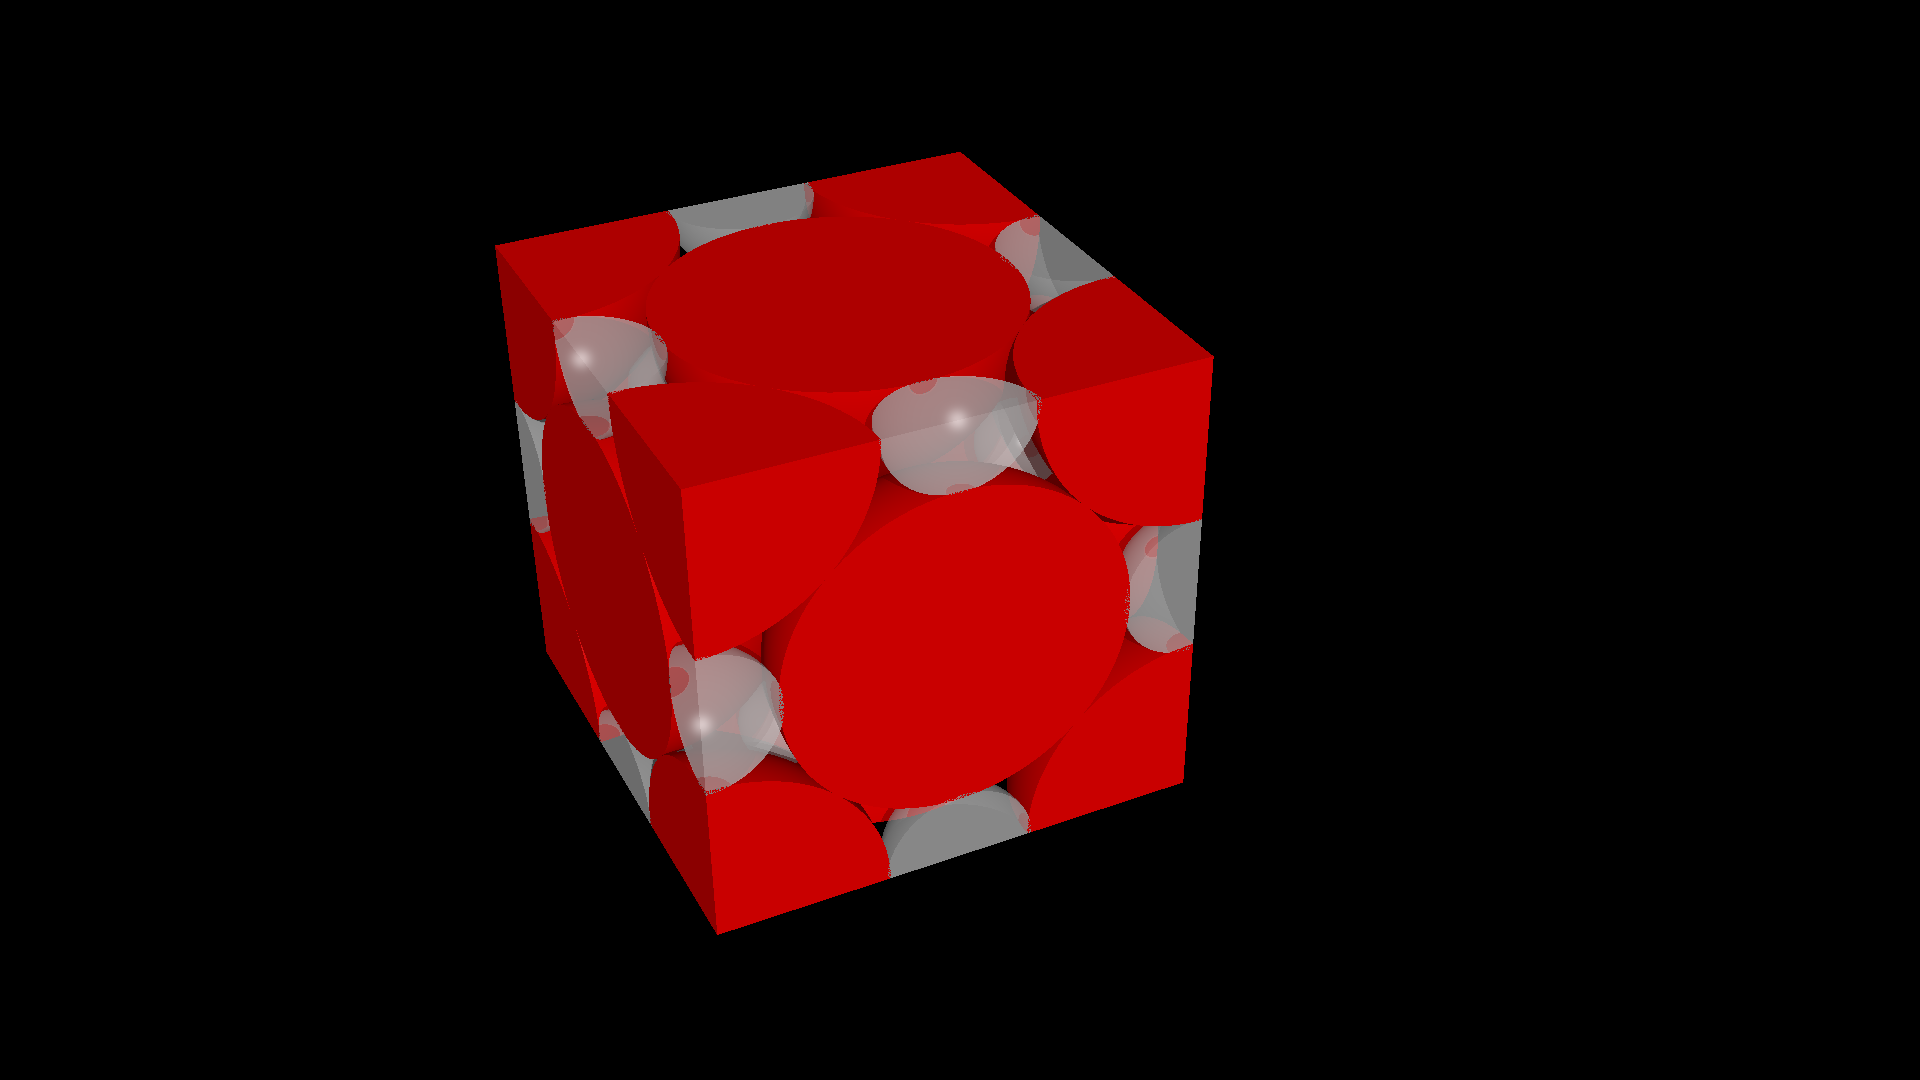

In [12]:
scene.renderScene("fcc-unit.png")
#scene.createSceneFile("x.pov")    # Optionally create a file to view generated SDL
Image(filename='fcc-unit.png')

#### Now re-slice cell at 3/4 height to reveal the smaller tetrahedral cavities (8 per cell):

POV-Ray render completed successfully.


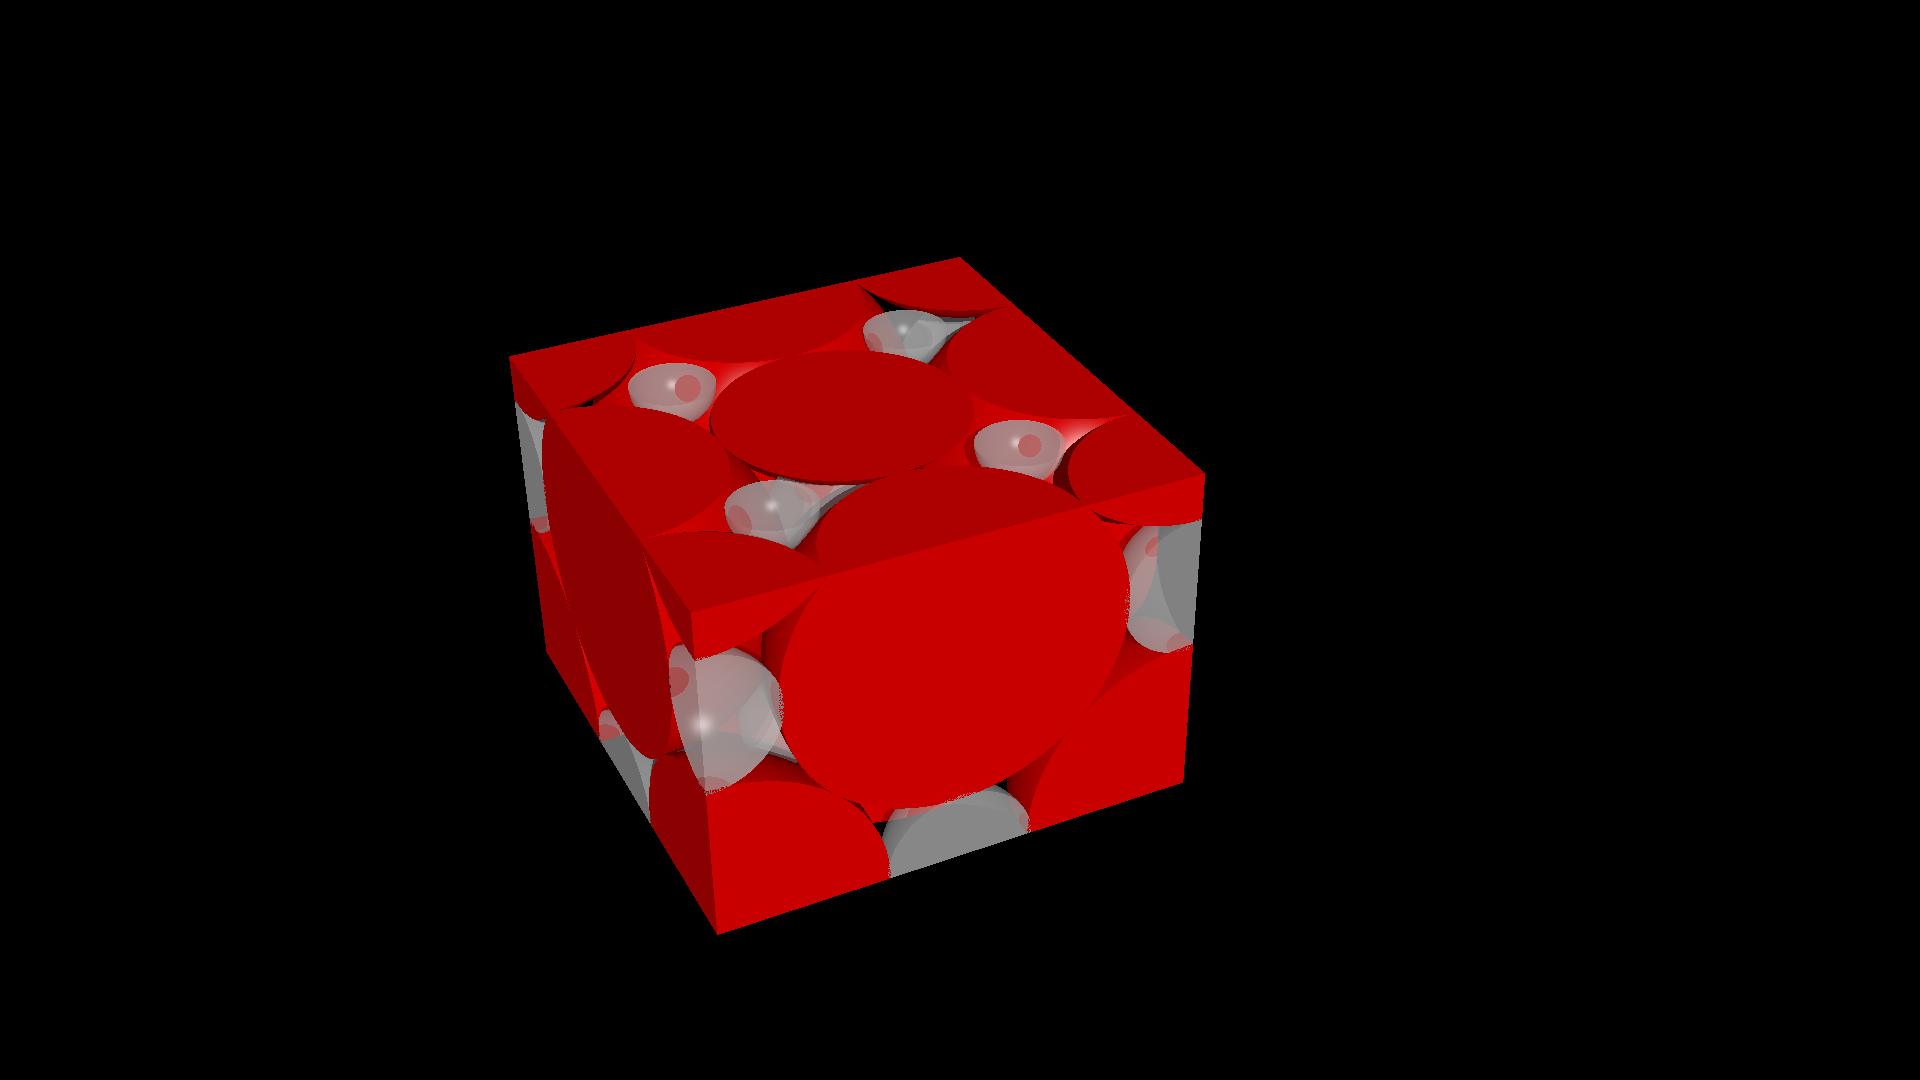

POV-Ray temporary file deleted successfully.


In [13]:
cc.setBoxDimensions([2,1.75,2])
cavc.setBoxDimensions([2,1.75,2])

scene.renderScene("fcc-tetra.png")
Image(filename='fcc-tetra.png')

## Free Volume Index (FVI)
Defined as the negative exponential of the repulsive component of the insertion energy, it ranges from 0.0 for occupied space to 1.0 for completely empty space. Data can be extracted as a 3D TIFF image, where the values have been mapped to the RGB channels of the output file.

In [14]:
fvi = v.FVIX(gfg)                 # Create the operation object
fvi.setDimensions([128,128,128])  # Set number of voxels for domain decomposition
fvi.execute()                     # will calculate energy, repulsion, attraction, and FVI
fvi.generateTIFF("fcc-unit.tiff") # Will generate a 3D tiff image reflecting the calculated FVI scalar field

#### Display the raw FVI TIFF image

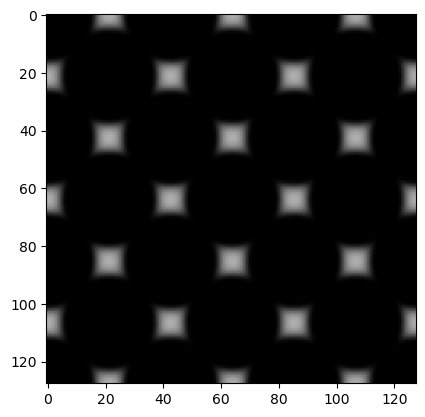

In [15]:
fcc = mpimg.imread('fcc-unit.tiff')
plt.imshow(fcc)
plt.show()

The generated TIFF image can be imported to Paraview to generate more compelling visualizations, such as those shown here:

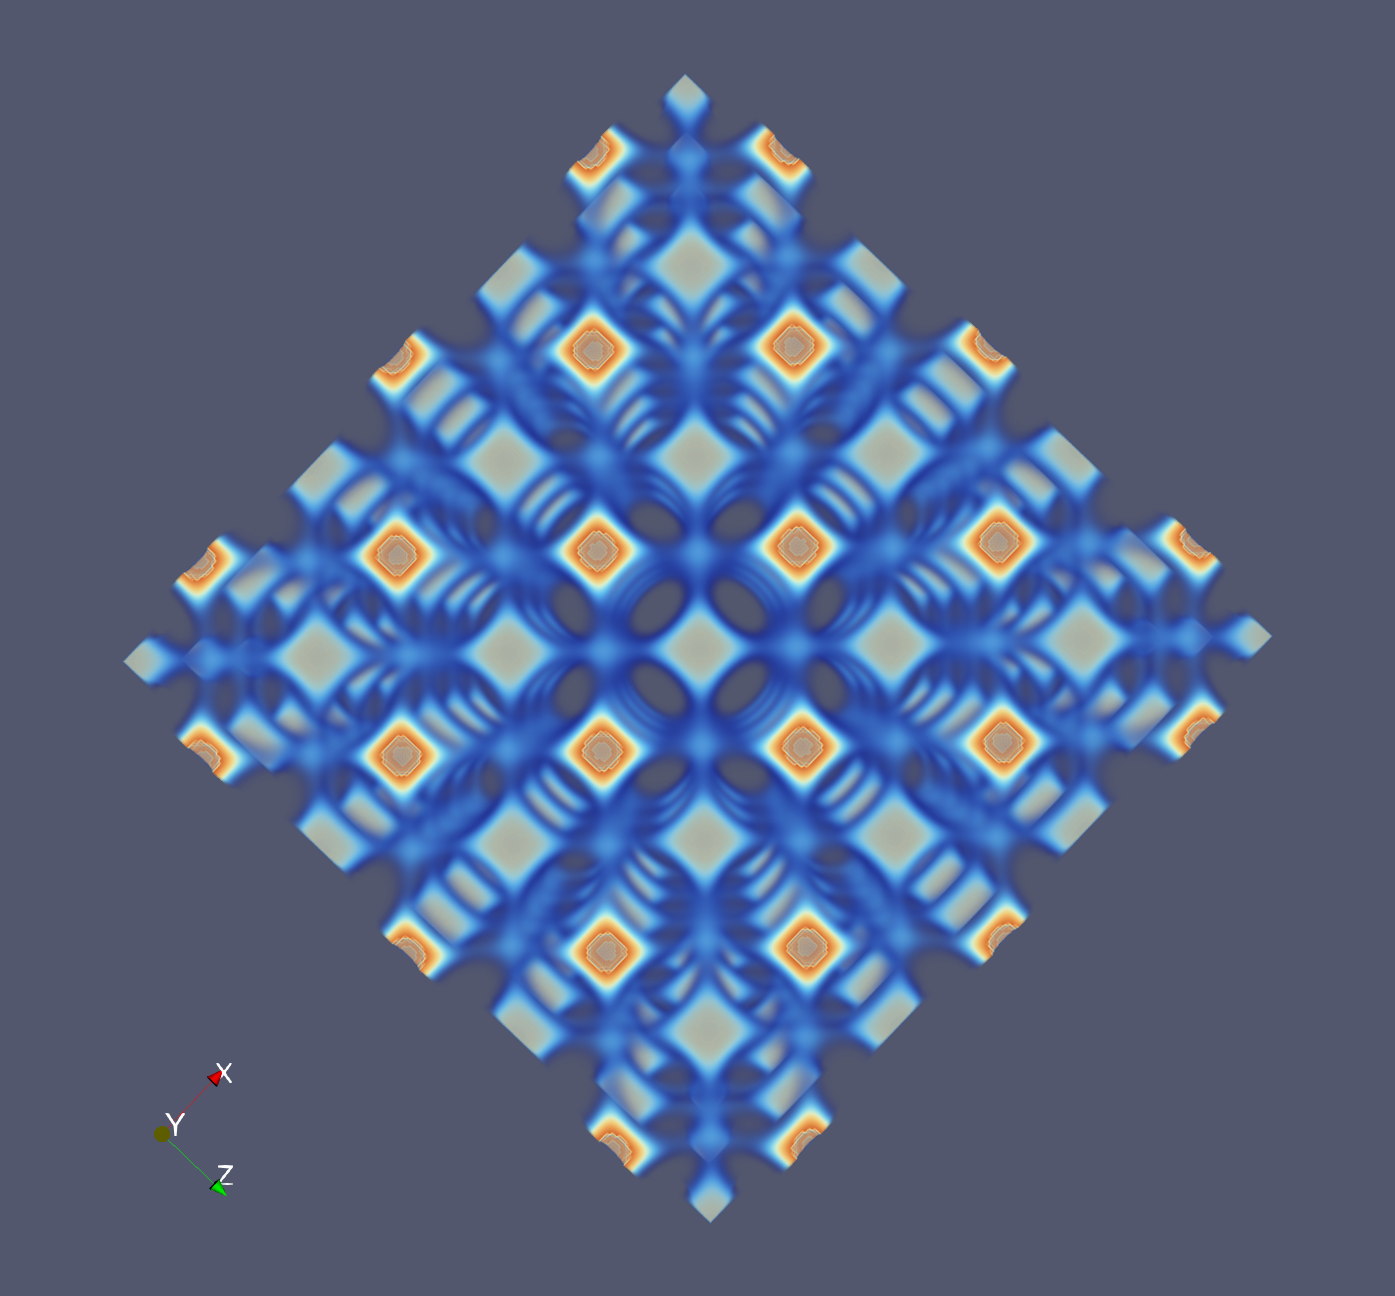

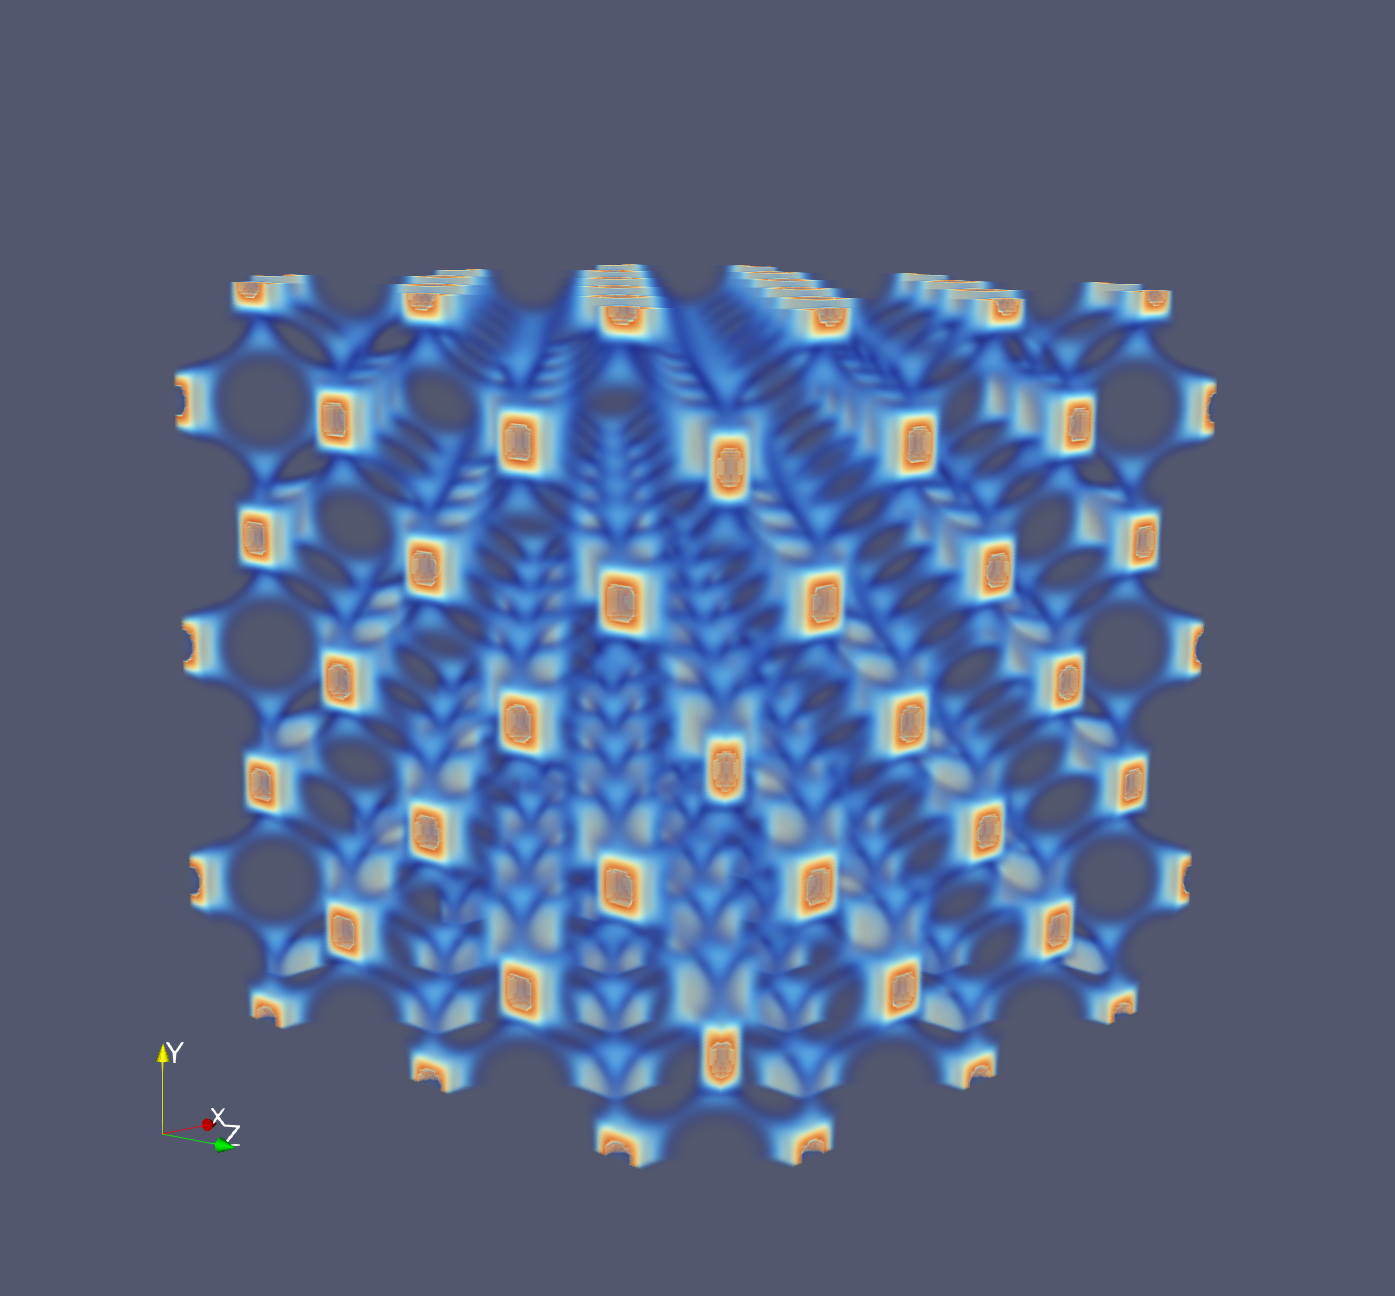

In [16]:
display(Image(filename='through.png', width=320), Image(filename='top.png', width=320))

#### Cavity size distributions and graphs
Standard plotting utilities can be invoked on the data in the cavity size distributions.

In [17]:
csd = v.CavitySizeDistribution(cavs)
csd.setBinWidth(0.025)
csd.setNumberOfBins(19)
csd.setStartingValue(0.0)
csd.generate()

#### Plot the original number distribution

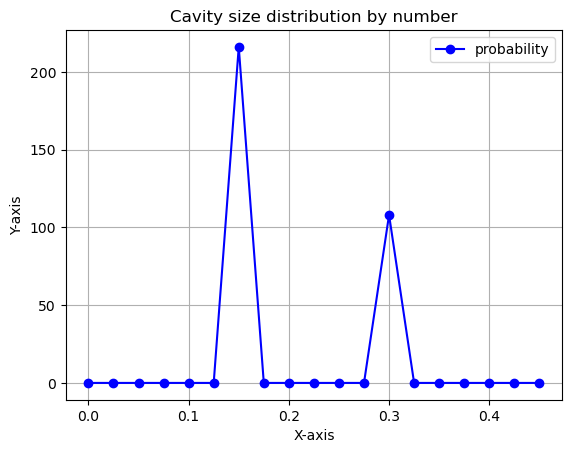

In [18]:
data=csd.getTuples()
x, y = zip(*data)

# Create the plot
plt.plot(x, y, marker='o', linestyle='-', color='b', label='probability')  # Line plot with markers
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Cavity size distribution by number')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

#### Re-weight to generate a volume distribution

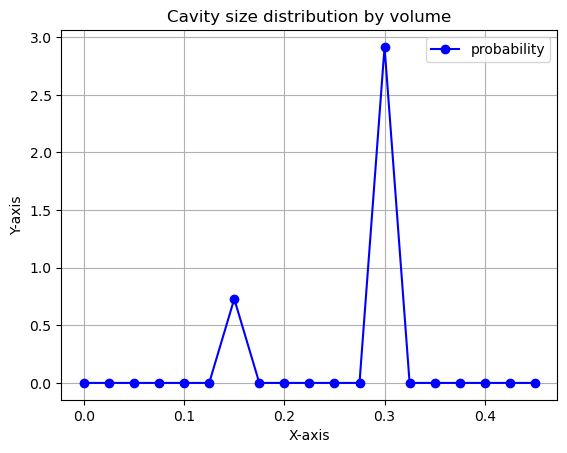

In [19]:
csd.applyWeightExponent(3)

data=csd.getTuples()
x, y = zip(*data)

# Create the plot
plt.plot(x, y, marker='o', linestyle='-', color='b', label='probability')  # Line plot with markers
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Cavity size distribution by volume')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()